<a href="https://colab.research.google.com/github/freddy-7/TI3002C/blob/main/4_Valores_at%C3%ADpicos_DataFrame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('Análisis_de_Piso_2_Sin_Nulos.csv') 

In [10]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Leads Prom X Mes             42 non-null     float64
 1   T. Ventas Piso               42 non-null     float64
 2   Factor                       42 non-null     float64
 3   Total de Ventas Historicas   42 non-null     float64
 4   RAKING VENTAS                42 non-null     str    
 5   Dependencia de Piso          42 non-null     float64
 6   Historico de PDM             42 non-null     float64
 7   Historico de SDC             42 non-null     float64
 8   Conversion PDM               42 non-null     float64
 9   Conversion SDC               42 non-null     float64
 10  Factor  PDM                  42 non-null     float64
 11  Factor  SDC                  42 non-null     float64
 12  Raking PDM                   42 non-null     float64
 13  Raking SDC                   42 n

In [ ]:
#convertimos la columna "RAKING VENTAS" a tipo numérico, reemplazando los valores "-" 
data["RAKING VENTAS"] = pd.to_numeric(
    data["RAKING VENTAS"].replace("-", np.nan),
    errors="coerce" 
)

data["RAKING VENTAS"].dtype

dtype('float64')

In [15]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Leads Prom X Mes             42 non-null     float64
 1   T. Ventas Piso               42 non-null     float64
 2   Factor                       42 non-null     float64
 3   Total de Ventas Historicas   42 non-null     float64
 4   RAKING VENTAS                31 non-null     float64
 5   Dependencia de Piso          42 non-null     float64
 6   Historico de PDM             42 non-null     float64
 7   Historico de SDC             42 non-null     float64
 8   Conversion PDM               42 non-null     float64
 9   Conversion SDC               42 non-null     float64
 10  Factor  PDM                  42 non-null     float64
 11  Factor  SDC                  42 non-null     float64
 12  Raking PDM                   42 non-null     float64
 13  Raking SDC                   42 n

In [16]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Leads Prom X Mes                0
T. Ventas Piso                  0
Factor                          0
Total de Ventas Historicas      0
RAKING VENTAS                  11
Dependencia de Piso             0
Historico de PDM                0
Historico de SDC                0
Conversion PDM                  0
Conversion SDC                  0
Factor  PDM                     0
Factor  SDC                     0
Raking PDM                      0
Raking SDC                      0
dtype: int64

In [17]:
#Sustituimos los valores nulos de RAKING VENTAS por 0
#El 0 representa que no existe un ranking

data["RAKING VENTAS"] = data["RAKING VENTAS"].fillna(0)

In [18]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Leads Prom X Mes               0
T. Ventas Piso                 0
Factor                         0
Total de Ventas Historicas     0
RAKING VENTAS                  0
Dependencia de Piso            0
Historico de PDM               0
Historico de SDC               0
Conversion PDM                 0
Conversion SDC                 0
Factor  PDM                    0
Factor  SDC                    0
Raking PDM                     0
Raking SDC                     0
dtype: int64

In [21]:
# Variables cuantitativas: columnas 0 a 14 (todas las columnas)
cuantitativas = data.iloc[:, 0:14]

# no hay variables cualitativas

<Figure size 1500x800 with 0 Axes>

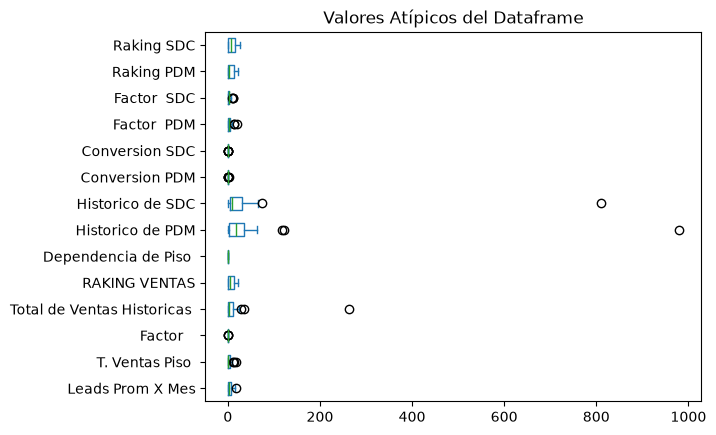

In [20]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

**Seleccionamos las variables en las que sí trataremos valores atípicos**

In [22]:
#Se identifico que en las columnas de "Total de Ventas Historicas", "Historico de SDC" y "Historico de PDM" los outliers extremos que aparecen son totales de las columnas
cuantitativas_atipicos = pd.concat([
    cuantitativas.iloc[:, 0:3],   #Columnas 0 a 2
    cuantitativas.iloc[:, 4:6],   #Columnas 4 y 5
    cuantitativas.iloc[:, 8:14]   #Columnas 8 a 13
], axis=1)

cuantitativas_atipicos

,Leads Prom X Mes,T. Ventas Piso,Factor,RAKING VENTAS,Dependencia de Piso,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
1,0.0,0.0,0.00,23.0,0.00,1.00,0.00,1.00,5.00,1.0,20.0
2,10.0,11.0,0.18,6.0,0.61,0.31,0.02,3.28,2.22,7.0,10.0
3,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
4,8.0,3.0,0.09,11.0,0.38,0.29,0.01,3.50,3.88,9.0,18.0
5,7.0,9.0,0.16,8.0,0.60,0.23,0.02,4.27,2.00,13.0,7.0
6,1.0,1.0,0.25,17.0,0.25,0.19,0.01,5.25,6.50,18.0,23.0
7,16.0,6.0,0.06,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
8,1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
9,2.0,0.0,0.00,19.0,0.00,0.08,0.00,12.50,11.00,22.0,26.0


In [36]:
#Seleccionamos las variables que excluimos del tratamiento de outliers

variables_excluidas = data.iloc[:, [3, 6, 7]]

variables_excluidas

,Total de Ventas Historicas,Historico de PDM,Historico de SDC
0,0.0,0.0,0.0
1,1.0,1.0,5.0
2,18.0,59.0,40.0
3,0.0,1.0,1.0
4,8.0,28.0,31.0
5,15.0,64.0,30.0
6,4.0,21.0,26.0
7,0.0,54.0,8.0
8,0.0,3.0,5.0
9,2.0,25.0,22.0


<Figure size 1500x800 with 0 Axes>

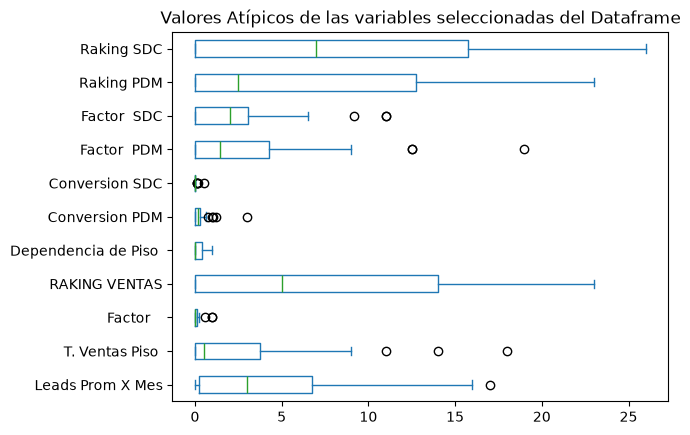

In [37]:
#Checar el diagrama de caja o bigote con los nuevos valores reemplazados
fig = plt.figure(figsize =(15, 8))
cuantitativas_atipicos.plot(kind='box', vert=False)
plt.title("Valores Atípicos de las variables seleccionadas del Dataframe")
plt.show() #dibujamos el diagrama

**PROCEDIMIENTO "DESVIACIÓN ESTÁNDAR" PARA ELIMINAR OUTLIERS EN DATAFRAME**

In [38]:
#Método aplicando desviación estandar. Encuentro los valores extremos
y=cuantitativas_atipicos
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Leads Prom X Mes        16.849670
T. Ventas Piso          14.938965
Factor                   0.788434
RAKING VENTAS           33.147785
Dependencia de Piso      1.127071
Conversion PDM           1.857461
Conversion SDC           0.280344
Factor  PDM             15.313678
Factor  SDC             11.124546
Raking PDM              30.337451
Raking SDC              35.529810
dtype: float64
Limite inferior permitido Leads Prom X Mes        -8.897289
T. Ventas Piso          -9.748489
Factor                  -0.568434
RAKING VENTAS          -17.243023
Dependencia de Piso     -0.692785
Conversion PDM          -1.280318
Conversion SDC          -0.225105
Factor  PDM             -9.310345
Factor  SDC             -6.321213
Raking PDM             -17.051737
Raking SDC             -18.482191
dtype: float64


In [39]:
#Obtenemos datos y los outliers se convierten en nulos en el DataFrame
data1= cuantitativas_atipicos[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data1

,Leads Prom X Mes,T. Ventas Piso,Factor,RAKING VENTAS,Dependencia de Piso,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
1,0.0,0.0,0.00,23.0,0.00,1.00,0.00,1.00,5.00,1.0,20.0
2,10.0,11.0,0.18,6.0,0.61,0.31,0.02,3.28,2.22,7.0,10.0
3,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
4,8.0,3.0,0.09,11.0,0.38,0.29,0.01,3.50,3.88,9.0,18.0
5,7.0,9.0,0.16,8.0,0.60,0.23,0.02,4.27,2.00,13.0,7.0
6,1.0,1.0,0.25,17.0,0.25,0.19,0.01,5.25,6.50,18.0,23.0
7,16.0,6.0,0.06,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
8,1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
9,2.0,0.0,0.00,19.0,0.00,0.08,0.00,12.50,11.00,22.0,26.0


In [40]:
#Corroboramos valores nulos del dataframe4
valores_nulos=data1.isnull().sum()
valores_nulos

Leads Prom X Mes        1
T. Ventas Piso          1
Factor                  2
RAKING VENTAS           0
Dependencia de Piso     0
Conversion PDM          1
Conversion SDC          1
Factor  PDM             1
Factor  SDC             0
Raking PDM              0
Raking SDC              0
dtype: int64

In [41]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data_clean=data1.copy()
data_clean=data_clean.fillna(round(data1.mean(),1))
data_clean

,Leads Prom X Mes,T. Ventas Piso,Factor,RAKING VENTAS,Dependencia de Piso,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
1,0.0,0.0,0.00,23.0,0.00,1.00,0.00,1.00,5.00,1.0,20.0
2,10.0,11.0,0.18,6.0,0.61,0.31,0.02,3.28,2.22,7.0,10.0
3,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
4,8.0,3.0,0.09,11.0,0.38,0.29,0.01,3.50,3.88,9.0,18.0
5,7.0,9.0,0.16,8.0,0.60,0.23,0.02,4.27,2.00,13.0,7.0
6,1.0,1.0,0.25,17.0,0.25,0.19,0.01,5.25,6.50,18.0,23.0
7,16.0,6.0,0.06,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
8,1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
9,2.0,0.0,0.00,19.0,0.00,0.08,0.00,12.50,11.00,22.0,26.0


In [42]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data_clean.isnull().sum()
valores_nulos

Leads Prom X Mes        0
T. Ventas Piso          0
Factor                  0
RAKING VENTAS           0
Dependencia de Piso     0
Conversion PDM          0
Conversion SDC          0
Factor  PDM             0
Factor  SDC             0
Raking PDM              0
Raking SDC              0
dtype: int64

**PROCEDIMIENTO "CUANTILES" PARA SUSTITUIR OUTLIERS EN DATAFRAME**

In [43]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas_atipicos

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido Leads Prom X Mes        16.50000
T. Ventas Piso           9.37500
Factor                   0.27500
RAKING VENTAS           35.00000
Dependencia de Piso      1.03125
Conversion PDM           0.72500
Conversion SDC           0.02500
Factor  PDM             10.61875
Factor  SDC              7.61250
Raking PDM              31.87500
Raking SDC              39.37500
dtype: float64
Limite inferior permitido Leads Prom X Mes        -9.50000
T. Ventas Piso          -5.62500
Factor                  -0.16500
RAKING VENTAS          -21.00000
Dependencia de Piso     -0.61875
Conversion PDM          -0.43500
Conversion SDC          -0.01500
Factor  PDM             -6.37125
Factor  SDC             -4.56750
Raking PDM             -19.12500
Raking SDC             -23.62500
dtype: float64


In [44]:
#Obtenemos datos limpios del Dataframe
data1_iqr= cuantitativas_atipicos[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data1_iqr

,Leads Prom X Mes,T. Ventas Piso,Factor,RAKING VENTAS,Dependencia de Piso,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
1,0.0,0.0,0.00,23.0,0.00,NaN,0.00,1.00,5.00,1.0,20.0
2,10.0,NaN,0.18,6.0,0.61,0.31,0.02,3.28,2.22,7.0,10.0
3,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
4,8.0,3.0,0.09,11.0,0.38,0.29,0.01,3.50,3.88,9.0,18.0
5,7.0,9.0,0.16,8.0,0.60,0.23,0.02,4.27,2.00,13.0,7.0
6,1.0,1.0,0.25,17.0,0.25,0.19,0.01,5.25,6.50,18.0,23.0
7,16.0,6.0,0.06,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
8,1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
9,2.0,0.0,0.00,19.0,0.00,0.08,0.00,NaN,NaN,22.0,26.0


In [45]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data1_iqr.isnull().sum()
valores_nulos

Leads Prom X Mes        1
T. Ventas Piso          3
Factor                  3
RAKING VENTAS           0
Dependencia de Piso     0
Conversion PDM          5
Conversion SDC          5
Factor  PDM             3
Factor  SDC             3
Raking PDM              0
Raking SDC              0
dtype: int64

In [46]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data2_iqr=data1_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data1_iqr.median(),1))
data2_iqr

,Leads Prom X Mes,T. Ventas Piso,Factor,RAKING VENTAS,Dependencia de Piso,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
1,0.0,0.0,0.00,23.0,0.00,0.10,0.00,1.00,5.00,1.0,20.0
2,10.0,0.0,0.18,6.0,0.61,0.31,0.02,3.28,2.22,7.0,10.0
3,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
4,8.0,3.0,0.09,11.0,0.38,0.29,0.01,3.50,3.88,9.0,18.0
5,7.0,9.0,0.16,8.0,0.60,0.23,0.02,4.27,2.00,13.0,7.0
6,1.0,1.0,0.25,17.0,0.25,0.19,0.01,5.25,6.50,18.0,23.0
7,16.0,6.0,0.06,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
8,1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
9,2.0,0.0,0.00,19.0,0.00,0.08,0.00,1.00,1.70,22.0,26.0


In [48]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([variables_excluidas, data2_iqr], axis=1)
Datos_limpios

,Total de Ventas Historicas,Historico de PDM,Historico de SDC,Leads Prom X Mes,T. Ventas Piso,Factor,RAKING VENTAS,Dependencia de Piso,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
1,1.0,1.0,5.0,0.0,0.0,0.00,23.0,0.00,0.10,0.00,1.00,5.00,1.0,20.0
2,18.0,59.0,40.0,10.0,0.0,0.18,6.0,0.61,0.31,0.02,3.28,2.22,7.0,10.0
3,0.0,1.0,1.0,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
4,8.0,28.0,31.0,8.0,3.0,0.09,11.0,0.38,0.29,0.01,3.50,3.88,9.0,18.0
5,15.0,64.0,30.0,7.0,9.0,0.16,8.0,0.60,0.23,0.02,4.27,2.00,13.0,7.0
6,4.0,21.0,26.0,1.0,1.0,0.25,17.0,0.25,0.19,0.01,5.25,6.50,18.0,23.0
7,0.0,54.0,8.0,16.0,6.0,0.06,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
8,0.0,3.0,5.0,1.0,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0,0.0
9,2.0,25.0,22.0,2.0,0.0,0.00,19.0,0.00,0.08,0.00,1.00,1.70,22.0,26.0


In [49]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Total de Ventas Historicas     0
Historico de PDM               0
Historico de SDC               0
Leads Prom X Mes               0
T. Ventas Piso                 0
Factor                         0
RAKING VENTAS                  0
Dependencia de Piso            0
Conversion PDM                 0
Conversion SDC                 0
Factor  PDM                    0
Factor  SDC                    0
Raking PDM                     0
Raking SDC                     0
dtype: int64

In [50]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Análisis_De_Piso_2_Sin_Atípicos.csv")